<a href="https://colab.research.google.com/github/Shlok-Joseph-Paul/physical-modeling-intuition/blob/main/Dimensional_Analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I want to estimate the average number of absorbed photons per quantum dot for a pulsed laser experiment. I expect this to depend on pulse energy, wavelength, beam area, and QD absorption cross-section.



| Variable | Meaning | Units |
|---|---|---|
| $E_p$ | Pulse energy | J |
| $\lambda$ | Wavelength | m |
| $A$ | Beam area | cm² |
| $\sigma$ | Absorption cross-section | cm²/QD |
| $N_\gamma$ | Photons per pulse | photons |
| $F_\gamma$ | Photon fluence | photons/cm² |
| $\langle N \rangle$ | Average excitons per QD | dimensionless |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.626e-34      # Planck constant [J s]
c = 2.998e8        # Speed of light [m/s]



In [19]:
# Experimental parameters

wavelength =      523E-9 # [m]
pulse_energy =      20E-6 # [J]
beam_radius =       1E-3  # [cm]
sigma_abs =         1E-15 # [cm^2 / QD]

In [20]:
# 1. Energy of one photon
photon_energy = (h*c)/wavelength # J/s * m * s/m = J


# 2. Number of photons in one pulse
photons_per_pulse = photon_energy/pulse_energy #photons


# 3. Area of the laser spot
beam_area = np.pi * beam_radius**2 # cm^2


# 4. Photon fluence
photon_fluence = photons_per_pulse/beam_area # photons/cm^2


# 5. Average number of absorbed photons / excitons per QD
N_avg = photon_fluence*sigma_abs

In [21]:
print(f"Photon energy:       {photon_energy:.3e} J")
print(f"Photons per pulse:   {photons_per_pulse:.3e}")
print(f"Beam area:           {beam_area:.3e} cm²")
print(f"Photon fluence:      {photon_fluence:.3e} photons/cm²")
print(f"<N>:                 {N_avg:.3f} excitons/QD")

Photon energy:       3.798e-19 J
Photons per pulse:   1.899e-14
Beam area:           3.142e-06 cm²
Photon fluence:      6.045e-09 photons/cm²
<N>:                 0.000 excitons/QD


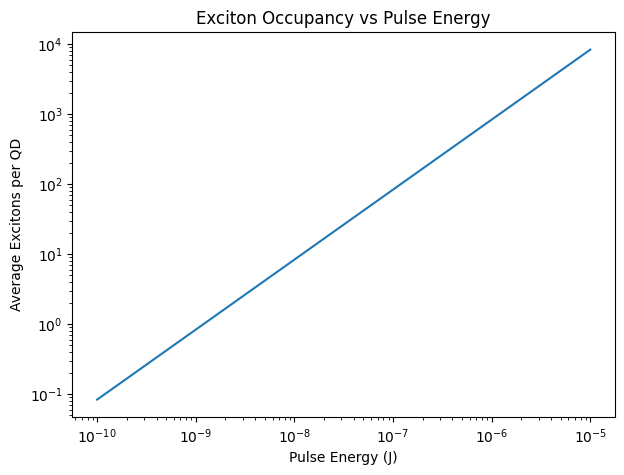

In [22]:
# Sweep pulse energy from 0.1 nJ to 10 µJ

pulse_energies = np.logspace(-10, -5, 100)

N_values = N_values = sigma_abs * (
    (pulse_energies / photon_energy) / beam_area
)

plt.figure(figsize=(7, 5))
plt.plot(pulse_energies, N_values)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Pulse Energy (J)")
plt.ylabel("Average Excitons per QD")
plt.title("Exciton Occupancy vs Pulse Energy")

plt.show()